# 25 DMOs -> fatigue

In [ ]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import DMOLSTM, ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.model import lstm_regression
from src.train import TrainRegression
from src.pipeline.dmo.dmo_into_dataloader import dmo_into_dataloader

import matplotlib.pyplot as plt

import numpy as np
import torch

In [ ]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
    "total_worn_h",
]

In [ ]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [ ]:
dmo_data = dmo_data.mean(axis=2)

In [ ]:
dmo_data = dmo_data.flatten(start_dim=0, end_dim=1)
dmo_data = dmo_data.unsqueeze(1)
dmo_labels = dmo_labels.flatten(start_dim=0, end_dim=1)
dmo_labels = dmo_labels.unsqueeze(dim=1)
print(dmo_data.shape)
print(dmo_labels.shape)

torch.Size([1400, 1, 25])
torch.Size([1400, 1, 1])


In [ ]:
transforms = (None, None)
training_dl, testing_dl = dmo_into_dataloader(dmo_data, dmo_labels, batch_size=16, transforms=transforms)

In [ ]:
model = DMOLSTM(config).to(device=device)
optimiser = config.optimiser(model.parameters(), lr=config.learning_rate)

trainer = TrainRegression(
    model,
    optimiser,
    config,
    training_dl,
    testing_dl,
    #training_dl,
    device,
    verbose=True,
)

trainer.train_loop()
prediction, actual = trainer.test_loop()


Testing loss: 0.07106287239326371


In [ ]:
print(prediction)
print(actual)

[tensor([[0.2621]]), tensor([[0.1456]]), tensor([[0.4238]]), tensor([[0.6482]]), tensor([[0.7913]]), tensor([[0.5807]]), tensor([[0.5683]]), tensor([[0.5365]]), tensor([[0.4426]]), tensor([[0.2514]]), tensor([[0.6501]]), tensor([[0.5215]]), tensor([[0.5664]]), tensor([[0.5457]]), tensor([[0.3166]]), tensor([[0.4286]]), tensor([[0.4899]]), tensor([[0.6076]]), tensor([[0.5465]]), tensor([[0.8497]]), tensor([[0.6014]]), tensor([[0.2347]]), tensor([[0.6576]]), tensor([[0.3848]]), tensor([[0.1691]]), tensor([[0.5400]]), tensor([[0.4580]]), tensor([[0.5874]]), tensor([[0.5548]]), tensor([[0.5441]]), tensor([[0.5598]]), tensor([[0.6837]]), tensor([[0.4529]]), tensor([[0.5540]]), tensor([[0.7429]]), tensor([[0.5945]]), tensor([[0.5335]]), tensor([[0.2918]]), tensor([[0.3896]]), tensor([[0.2591]]), tensor([[0.4349]]), tensor([[0.3112]]), tensor([[0.5866]]), tensor([[0.5311]]), tensor([[0.5121]]), tensor([[0.6706]]), tensor([[0.5398]]), tensor([[0.3291]]), tensor([[0.6494]]), tensor([[0.6027]]),

All metrics: {'accuracy': 0.30357142857142855, 'Mean Squared Error': 0.06959177553653717, 'Mean Absolute Error': 0.2132405936717987, 'R^2': -0.24211883544921875}


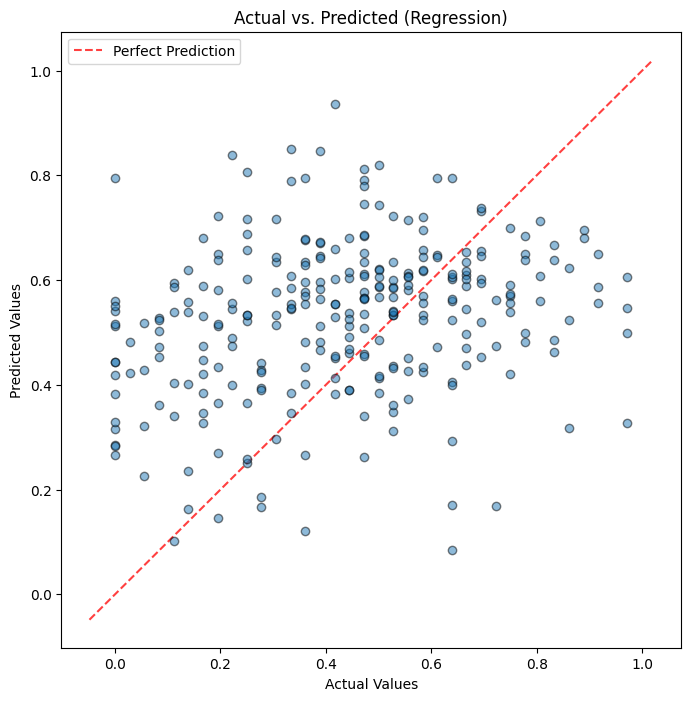

In [ ]:
from src.evaluation import Evaluation

actual_values = torch.Tensor(actual)
predicted_values = torch.Tensor(prediction)

evaluation = Evaluation(predicted_values, actual_values)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
